___
# Analysis of the radical OH species
___
# NPT
Molecular dynamics at the isobaric and isothermal ensemble was run for 100 ps at 350 K and 1.0 bar pressure in order to obtain an estimate of the liquid density.

The section below contains estimates of thermodynamic properties and the liquid structure in the form of RDFs and heatmaps which contain angular information around the hydroxyl-molecule.

## Building the trajectory

In [1]:
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chempiler import ChempilerTrajectory, plot_rdf, diffusive_window
from chempiler.state_engine import atom_hop, ligand_exchange

import tol_colors as tc
cset = tc.bright

plt.rcParams.update({
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.prop_cycle': plt.cycler(color=cset)
})

dt = 0.5 # fs
TEMPERATURE = 350.0 # K
PRESSURE = 1.0 # bar
DUMP_INTERVAL = 10

data_path = '../../data'

NPT_LOGFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH.log'
NPT_CALCFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH_calc.h5' # This should maybe not be loaded at this stage...
NPT_TRAJFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH.traj'

In [2]:
print('Reading OH• NPT trajectory...')
npt_traj = ChempilerTrajectory(
    NPT_TRAJFILE,
    mode='molecular', covalent_scale=0.8, # NOTE: The small covalent scale is important to capture the O-H bond in the ion. To avoid seeing clusters of water molecules as bonded. IS THIS A MOTIF 'ISSUE'?
)
print('Building topology...')
npt_traj.build(
    cache_file='tests/OH_rad_npt_cache.h5', # <--------------------------------------------- Consider changing the name of this directory
    companion=NPT_CALCFILE, # Consider dropping this if not part of the analysis...
    persistence=3, # Check if covalen_scale=1.0 works with a different persistence...
)
print('Done.')
print('Molecular species in trajectory:')
npt_traj.summary()

Reading OH• NPT trajectory...
Building topology...
[Chempiler] loaded cache → tests/OH_rad_npt_cache.h5
[Chempiler] persistence=3: corrected 1 frames
[Chempiler] companion attached → ../../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/39_water_OH_calc.h5 (20001 frames, 14 properties: charges, density_coefficients, dipole, electron_energy, electrostatic_energy, energies, energy, forces, free_energy, interaction_energy, node_energy, spin_charge_density, spins, stress)
Done.
Molecular species in trajectory:


{'H2O': 780033, 'HO': 20001, 'H4O2': 3}

## Summary of molecular species
Shown below is the segmentation of the trajectory based on molecular composition. **Three frames contain dimers that are *very* close together.**

,n_segs,coverage,min,median,mean,max
formula,,,,,,
H2O,1,100.0%,20001,20001,20001.0,20001
HO,1,100.0%,20001,20001,20001.0,20001
H4O2,1,0.0%,3,3,3.0,3


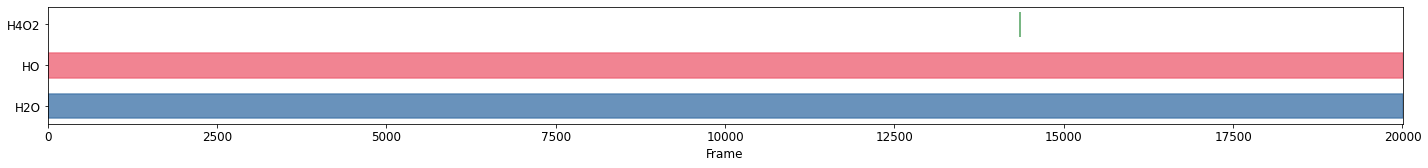

In [20]:
# Dataframe
rows = []
for formula, _ in npt_traj.summary().items():
    segs = npt_traj.lifetime_segments(formula)
    lengths = np.array([e - s for s, e in segs])
    covered = lengths.sum()
    rows.append({
        'formula':  formula,
        'n_segs':   len(segs),
        'coverage': f"{100 * covered / len(npt_traj.frames):.1f}%",
        'min':      int(lengths.min()),
        'median':   int(np.median(lengths)),
        'mean':     f"{lengths.mean():.1f}",
        'max':      int(lengths.max()),
    })

species = sorted(npt_traj.summary().keys(), key=lambda f: -npt_traj.summary()[f])
fig, ax = plt.subplots(figsize=(20, 0.5 * len(species) + 1))

for i, (row_colour, formula) in enumerate( zip(cset, species) ):
    for s, e in npt_traj.lifetime_segments(formula):
        ax.barh(i, e - s, left=s, height=0.6, color=row_colour, alpha=0.8, edgecolor=row_colour, linewidth=1.5)

ax.set_yticks(range(len(species)))
ax.set_yticklabels(species)
ax.set_xlabel('Frame')
ax.set_xlim(0, len(npt_traj.frames))
plt.tight_layout()

pd.DataFrame(rows).set_index('formula')


## Thermodynamic properties
Thermodynamic properties were computed with block statistics. The independence of each block was ascertained by estimating the correlation times, $\tau$ (in dumped frames), and setting the block length to $10\tau$ (`block_factor = 10`) so that adjacent blocks are effectively uncorrelated.

The output is a *block average* (`mean`) and *standard error of the mean* (`stderr`): 
$$
\texttt{stderr} = \frac{\sigma_{\texttt{block}}}{\sqrt{\texttt{n\_blocks}}}
$$

**Results:**

In [ ]:
import json

import utils.helper_funcs as hf
import utils.thermo_funcs as tf


NPT_paths = {
    'OH$^*$(aq)': '/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NPT/',
}
npt_cache_file = 'results/NPT/OH_radical_thermo_props.json'


try:
    with open(npt_cache_file, 'r') as f:
        cached_npt_props = json.load(f)
    print("Loaded cached thermodynamic properties.")
    correlation_times = cached_npt_props['correlation_times']
    block_factor = cached_npt_props['block_factor'] # Number of correlation times between uncorrelated blocks

except FileNotFoundError:
    print("No cache found: Computing correlation times and thermodynamic properties.")
    block_factor = 10 # Number of correlation times between uncorrelated blocks

    # Compute correlation times
    npt_traj_data = hf.load_data(
        NPT_paths,
        fname='*.traj',
        root_dir=data_path
    )

    # Check for unreliable estimates
    tau_dict, unreliable = tf.estimate_correlation_times(npt_traj_data)
    if unreliable:
        print('Unreliable correlation-time estimates:', unreliable)

    # Round to whole frames
    correlation_times = {
        prop: round(tau) for prop, tau in tau_dict['OH$^*$(aq)'].items()
    }

npt_thermo_df = hf.cached_thermo_props(
    npt_cache_file,
    NPT_paths,
    data_path,
    temperature=TEMPERATURE,
    correlation_times=correlation_times,
    block_factor=block_factor,
)
npt_thermo_df

Loaded cached thermodynamic properties.
Loaded thermodynamic properties from results/NPT/OH_radical_thermo_props.json
  correlation_times used: {'volume': 93, 'density': 93, 'enthalpy': 75, 'pressure': 1, 'heat_capacity': 75, 'compressibility': 93, 'bulk_modulus': 93, 'thermal_expansion': 93}
  temperature used: 350.0
  block_factor used: 10


## Liquid structure
The simulation box is very small so only the early peaks can be properly assessed. The automated `rmax` is based on the *smallest* box size across the NPT trajectory.

The $\text{O}_\text{rad} \cdots \text{O}_\text{w}$ species show a clear peak located at the **hemi-bond** distance, **corresponding to the O\*-O1 coordination**.

[Chempiler] loaded RDF cache → results/NPT/rdf_Orad_Ow.json
  Peaks:   2.125,  2.975,  4.725
  CNs:     1.017,  11.779,  20.124
[Chempiler] loaded RDF cache → results/NPT/rdf_Orad_Hw.json
  Peaks:   2.325,  3.325
  CNs:     5.558,  41.088
[Chempiler] loaded RDF cache → results/NPT/rdf_Hrad_Ow.json
  Peaks:   2.175,  3.325
  CNs:     2.414,  20.409


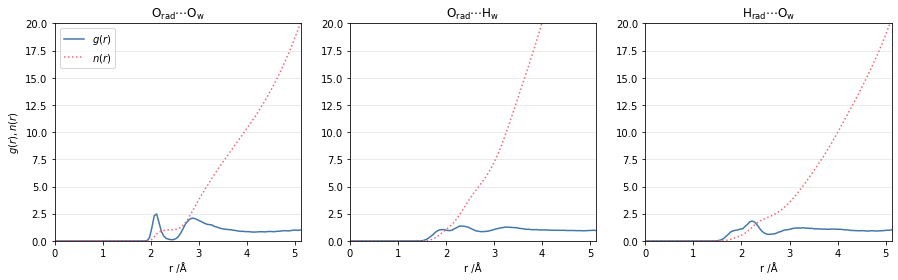

In [13]:
from chempiler import rdf_shells

npt_plts = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"HO": "O"}, {"H2O": "O"}, 'results/NPT/rdf_Orad_Ow.json'),
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': ({"HO": "O"}, {"H2O": "H"}, 'results/NPT/rdf_Orad_Hw.json'),
    '$\\text{H}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"HO": "H"}, {"H2O": "O"}, 'results/NPT/rdf_Hrad_Ow.json'),
}

fig, axs = plt.subplots(1,3, figsize=(3*5, 4))
for ax, (label, pair) in zip(axs, npt_plts.items()):
    CTR, TGT, CACHE = pair

    r, g, n = npt_traj.rdf(
        center=CTR,
        target=TGT,
        dr=0.05,
        integrate=True,
        cache_file=CACHE,
    )
    shells = rdf_shells(r, g, n, smooth_sigma=0.2)

    peaks = [str(p) for p in shells.peaks.round(decimals=3)]; print('  Peaks:  ', ',  '.join(peaks))
    cns = [str(c) for c in shells.cns.round(decimals=3)]; print('  CNs:    ', ',  '.join(cns))

    ax.plot(r,g, label='$g(r)$')
    ax.plot(r,n, ':', label='$n(r)$')

    ax.set_title(label)
    ax.set_xlabel('r /Å')
    ax.set_xlim(0,r.max())
    ax.set_ylim(0,20)
    ax.grid(axis='y')

axs[0].set_ylabel('$g(r), n(r)$')
axs[0].legend();

In [ ]:
from chempiler import spatial_density_maps

npt_targets = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"H2O": "O"}, 'results/NPT/sdf_Orad_Ow.h5'),
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': ({"H2O": "H"}, 'results/NPT/sdf_Orad_Hw.h5'),
}

npt_panels = {
    label: spatial_density_maps(
        npt_traj.frames if len(npt_traj.frames) > 0 else [],
        center={"HO": "O"},
        align_to={"HO": "H"},
        target=pair,
        symmetry='Cinfv',
        rmax=5.0, bins=75, stride=1,
        cache_file=cache,
    )
    for label, (pair, cache) in npt_targets.items()
}

[Chempiler] loaded SDF cache → results/NPT/sdf_Orad_Ow.h5
[Chempiler] loaded SDF cache → results/NPT/sdf_Orad_Hw.h5


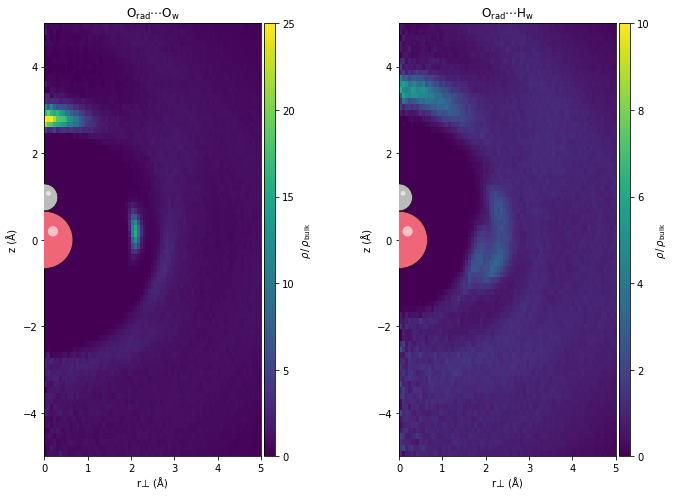

In [ ]:
from chempiler import plot_sdf

fig, axs = plt.subplots(1, len(npt_panels), figsize=(5 * len(npt_panels), 7))

vmax_map = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': 25,
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': 10,
}

for ax, (label, data) in zip(axs, npt_panels.items()):
    ax.plot_sdf(
        data,
        projection='cylindrical',
        center_symbol='O',
        align_symbol='H',
        normalize='density',
        cmap='viridis',
        vmax=vmax_map[label],
    )
    ax.set_title(label)

plt.tight_layout()

# NVT
Molecular dynamics at the isothermal ensemble was run for 200 ps at 350 K at the density obtained from the NPT simulation whose results aare presented above.

The section below contains estimates of thermodynamic properties and the liquid structure in the form of RDFs and heatmaps which contain angular information around the hydroxyl-molecule.

## Building the trajectory

In [3]:
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chempiler import ChempilerTrajectory, plot_rdf, diffusive_window
from chempiler.state_engine import atom_hop, ligand_exchange

import tol_colors as tc
cset = tc.bright

plt.rcParams.update({
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.prop_cycle': plt.cycler(color=cset)
})

dt = 0.5 # fs
TEMPERATURE = 350.0 # K
DUMP_INTERVAL = 10

data_path = '../../data'

NVT_LOGFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NVT/39_water_OH.log'
NVT_CALCFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NVT/39_water_OH_calc.h5' # This should maybe not be loaded at this stage...
NVT_TRAJFILE = data_path+'/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NVT/39_water_OH.traj'

In [4]:
print('Reading OH• NVT trajectory...')
nvt_traj = ChempilerTrajectory(
    NVT_TRAJFILE,
    mode='molecular', covalent_scale=0.8, # NOTE: The small covalent scale is important to capture the O-H bond in the ion. To avoid seeing clusters of water molecules as bonded. IS THIS A MOTIF 'ISSUE'?
)
print('Building topology...')
nvt_traj.build(
    cache_file='tests/OH_rad_nvt_cache.h5', # <--------------------------------------------- Consider changing the name of this directory
    companion=NVT_CALCFILE, # Consider dropping this if not part of the analysis...
    persistence=3, # Check if covalen_scale=1.0 works with a different persistence...
)
print('Done.')
print('Molecular species in trajectory:')
nvt_traj.summary()

Reading OH• NVT trajectory...
Building topology...
[Chempiler] loaded cache → tests/OH_rad_nvt_cache.h5
[Chempiler] persistence=3: corrected 8 frames
[Chempiler] companion attached → ../../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NVT/39_water_OH_calc.h5 (40001 frames, 14 properties: charges, density_coefficients, dipole, electron_energy, electrostatic_energy, energies, energy, forces, free_energy, interaction_energy, node_energy, spin_charge_density, spins, stress)
Done.
Molecular species in trajectory:


{'H2O': 1560039, 'HO': 40001}

## Summary of molecular species
Shown below is the segmentation of the trajectory based on molecular composition.

,n_segs,coverage,min,median,mean,max
formula,,,,,,
H2O,1,100.0%,40001,40001,40001.0,40001
HO,1,100.0%,40001,40001,40001.0,40001


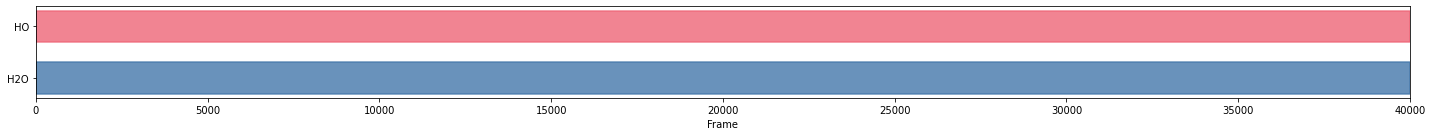

In [5]:
# Dataframe
rows = []
for formula, _ in nvt_traj.summary().items():
    segs = nvt_traj.lifetime_segments(formula)
    lengths = np.array([e - s for s, e in segs])
    covered = lengths.sum()
    rows.append({
        'formula':  formula,
        'n_segs':   len(segs),
        'coverage': f"{100 * covered / len(nvt_traj.frames):.1f}%",
        'min':      int(lengths.min()),
        'median':   int(np.median(lengths)),
        'mean':     f"{lengths.mean():.1f}",
        'max':      int(lengths.max()),
    })

species = sorted(nvt_traj.summary().keys(), key=lambda f: -nvt_traj.summary()[f])
fig, ax = plt.subplots(figsize=(20, 0.5 * len(species) + 1))

for i, (row_colour, formula) in enumerate( zip(cset, species) ):
    for s, e in nvt_traj.lifetime_segments(formula):
        ax.barh(i, e - s, left=s, height=0.6, color=row_colour, alpha=0.8, edgecolor=row_colour, linewidth=1.5)

ax.set_yticks(range(len(species)))
ax.set_yticklabels(species)
ax.set_xlabel('Frame')
ax.set_xlim(0, len(nvt_traj.frames))
plt.tight_layout()

pd.DataFrame(rows).set_index('formula')

## Thermodynamic properties
Thermodynamic properties were computed with block statistics. The independence of each block was ascertained by estimating the correlation times, $\tau$ (in dumped frames), and setting the block length to $10\tau$ (`block_factor = 10`) so that adjacent blocks are effectively uncorrelated.

The output is a *block average* (`mean`) and *standard error of the mean* (`stderr`): 
$$
\texttt{stderr} = \frac{\sigma_{\texttt{block}}}{\sqrt{\texttt{n\_blocks}}}
$$

**Results:**

In [9]:
import json

import utils.helper_funcs as hf
import utils.thermo_funcs as tf


NVT_paths = {
    'OH$^*$(aq)': '/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NVT/',
}
nvt_cache_file = 'results/NVT/OH_radical_thermo_props.json'


try:
    with open(nvt_cache_file, 'r') as f:
        cached_nvt_props = json.load(f)
    print("Loaded cached thermodynamic properties.")
    correlation_times = cached_nvt_props['correlation_times']
    block_factor = cached_nvt_props['block_factor'] # Number of correlation times between uncorrelated blocks

except FileNotFoundError:
    print("No cache found: Computing correlation times and thermodynamic properties.")
    block_factor = 10 # Number of correlation times between uncorrelated blocks

    # Compute correlation times
    nvt_traj_data = hf.load_data(
        NVT_paths,
        fname='*.traj',
        root_dir=data_path
    )

    # Check for unreliable estimates
    tau_dict, unreliable = tf.estimate_correlation_times(nvt_traj_data)
    if unreliable:
        print('Unreliable correlation-time estimates:', unreliable)

    # Round to whole frames
    correlation_times = {
        prop: round(tau) for prop, tau in tau_dict['OH$^*$(aq)'].items()
    }

nvt_thermo_df = hf.cached_thermo_props(
    nvt_cache_file,
    NVT_paths,
    data_path,
    temperature=TEMPERATURE,
    correlation_times=correlation_times,
    block_factor=block_factor,
)
nvt_thermo_df

No cache found: Computing correlation times and thermodynamic properties.
Loading data for 'OH$^*$(aq)' from '../../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NVT/39_water_OH.traj'
results/NVT/OH_radical_thermo_props.json not found. Computing thermodynamic properties...
Loading trajectory data...
Loading data for 'OH$^*$(aq)' from '../../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/NVT/39_water_OH.traj'
Finished loading trajectory data.
Computing thermodynamic properties...
Saved thermodynamic properties to results/NVT/OH_radical_thermo_props.json


## Liquid structure
The simulation box is very small so only the early peaks can be properly assessed.

The $\text{O}_\text{rad} \cdots \text{O}_\text{w}$ species show a clear peak located at the **hemi-bond** distance, **corresponding to the O\*-O1 coordination**. ??????????????????????

[Chempiler] loaded RDF cache → results/NVT/rdf_Orad_Ow.json
  Peaks:   2.125,  2.975,  4.675
  CNs:     1.008,  12.602,  20.223
[Chempiler] loaded RDF cache → results/NVT/rdf_Orad_Hw.json
  Peaks:   2.325,  3.375
  CNs:     5.492,  41.126
[Chempiler] loaded RDF cache → results/NVT/rdf_Hrad_Ow.json
  Peaks:   2.175,  3.375
  CNs:     2.379,  20.441


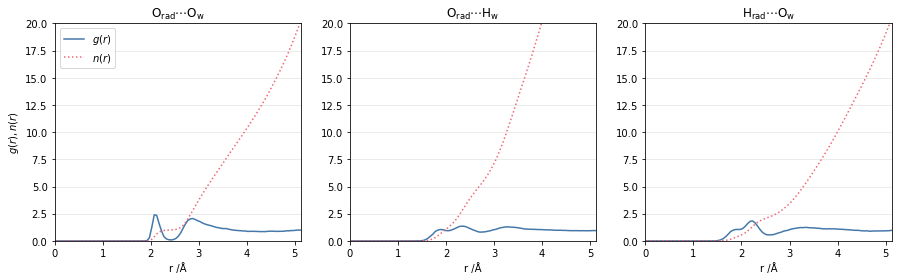

In [12]:
from chempiler import rdf_shells

nvt_plts = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"HO": "O"}, {"H2O": "O"}, 'results/NVT/rdf_Orad_Ow.json'),
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': ({"HO": "O"}, {"H2O": "H"}, 'results/NVT/rdf_Orad_Hw.json'),
    '$\\text{H}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"HO": "H"}, {"H2O": "O"}, 'results/NVT/rdf_Hrad_Ow.json'),
}

fig, axs = plt.subplots(1,3, figsize=(3*5, 4))
for ax, (label, pair) in zip(axs, nvt_plts.items()):
    CTR, TGT, CACHE = pair

    r, g, n = nvt_traj.rdf(
        center=CTR,
        target=TGT,
        dr=0.05,
        integrate=True,
        cache_file=CACHE,
    )
    shells = rdf_shells(r, g, n, smooth_sigma=0.2)

    peaks = [str(p) for p in shells.peaks.round(decimals=3)]; print('  Peaks:  ', ',  '.join(peaks))
    cns = [str(c) for c in shells.cns.round(decimals=3)]; print('  CNs:    ', ',  '.join(cns))

    ax.plot(r,g, label='$g(r)$')
    ax.plot(r,n, ':', label='$n(r)$')

    ax.set_title(label)
    ax.set_xlabel('r /Å')
    ax.set_xlim(0,r.max())
    ax.set_ylim(0,20)
    ax.grid(axis='y')

axs[0].set_ylabel('$g(r), n(r)$')
axs[0].legend();

In [14]:
from chempiler import spatial_density_maps

nvt_targets = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': ({"H2O": "O"}, 'results/NVT/sdf_Orad_Ow.h5'),
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': ({"H2O": "H"}, 'results/NVT/sdf_Orad_Hw.h5'),
}

nvt_panels = {
    label: spatial_density_maps(
        nvt_traj.frames if len(nvt_traj.frames) > 0 else [],
        center={"HO": "O"},
        align_to={"HO": "H"},
        target=pair,
        symmetry='Cinfv',
        rmax=5.0, bins=75, stride=1,
        cache_file=cache,
    )
    for label, (pair, cache) in nvt_targets.items()
}

[Chempiler] saved SDF cache → results/NVT/sdf_Orad_Ow.h5
[Chempiler] saved SDF cache → results/NVT/sdf_Orad_Hw.h5


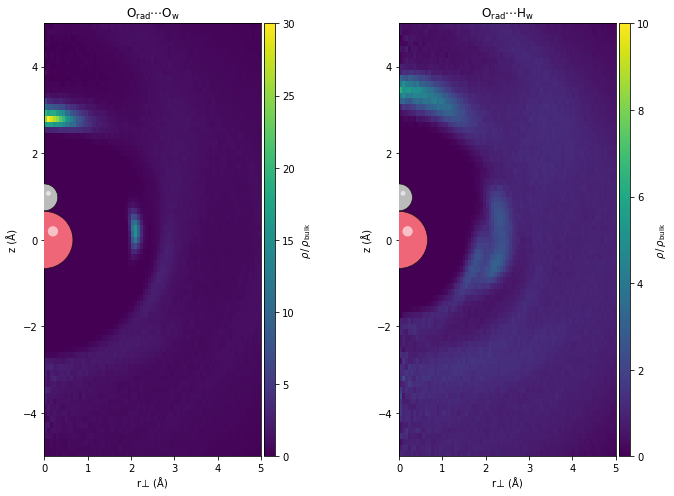

In [20]:
from chempiler import plot_sdf

fig, axs = plt.subplots(1, len(nvt_panels), figsize=(5 * len(nvt_panels), 7))

vmax_map = {
    '$\\text{O}_\\text{rad} \\cdots \\text{O}_\\text{w}$': 30,
    '$\\text{O}_\\text{rad} \\cdots \\text{H}_\\text{w}$': 10,
}

for ax, (label, data) in zip(axs, nvt_panels.items()):
    ax.plot_sdf(
        data,
        projection='cylindrical',
        center_symbol='O',
        align_symbol='H',
        normalize='density',
        cmap='viridis',
        vmax=vmax_map[label],
    )
    ax.set_title(label)

plt.tight_layout()

# Cluster analysis

## Coordination analysis
**This should move to NVT once those results are finished.**
### PCA
Here we show PCA across nearest neighbour distances. The analysis was done on standardised distance despite all of them having the same unit because they have systematically different values. However, for comparison, non-standardised PCA was also done. Although the numerical results differed, a subsequent but brief check gave similar interpratations to what follows below.

In [ ]:
import pandas as pd
import numpy as np

nearest4 = nvt_traj.nearest_distances(
    center={'HO': 'O'},
    target={'H2O': 'O'},
    n_max=4,
    stride=1,
)

nearest_df = pd.DataFrame(nearest4, columns=['nn1', 'nn2', 'nn3', 'nn4'])
nearest_df.index.name = 'frame'
nearest_df.head()

,nn1,nn2,nn3,nn4
frame,,,,
0,2.134791,2.743511,2.804684,2.851134
1,2.199556,2.723308,2.800452,2.823216
2,2.246550,2.720994,2.791903,2.795915
3,2.273739,2.748629,2.763383,2.787747
4,2.286877,2.741250,2.780875,2.781895


The correlation below shows that there is low likelihood that any of the `nn`'s are collinear. The first histogram plot shows separated groups whereas the second histogram reveals a distribution that is bi-, rather than tetramodal. From these figures we see that nn1 mostly correspond to the O1 position and the remaining nn3, nn3, and nn4 to the other sites.

          nn1       nn2       nn3       nn4
nn1  1.000000 -0.170663 -0.055883  0.001215
nn2 -0.170663  1.000000  0.572354  0.362787
nn3 -0.055883  0.572354  1.000000  0.679432
nn4  0.001215  0.362787  0.679432  1.000000


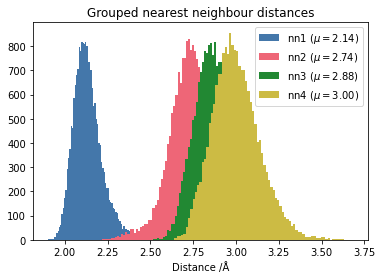

In [10]:
print(nearest_df.corr())

fig, ax = plt.subplots()

nbins = 'fd'
htype = 'bar'

ax.hist(nearest_df['nn1'], bins=nbins, histtype=htype, label=f"nn1 ($\\mu={nearest_df['nn1'].mean():.2f}$)")
ax.hist(nearest_df['nn2'], bins=nbins, histtype=htype, label=f"nn2 ($\\mu={nearest_df['nn2'].mean():.2f}$)")
ax.hist(nearest_df['nn3'], bins=nbins, histtype=htype, label=f"nn3 ($\\mu={nearest_df['nn3'].mean():.2f}$)")
ax.hist(nearest_df['nn4'], bins=nbins, histtype=htype, label=f"nn4 ($\\mu={nearest_df['nn4'].mean():.2f}$)")

ax.set_title('Grouped nearest neighbour distances')
ax.set_xlabel('Distance /Å')
ax.legend();

          nn1       nn2       nn3       nn4
nn1  1.000000 -0.170663 -0.055883  0.001215
nn2 -0.170663  1.000000  0.572354  0.362787
nn3 -0.055883  0.572354  1.000000  0.679432
nn4  0.001215  0.362787  0.679432  1.000000


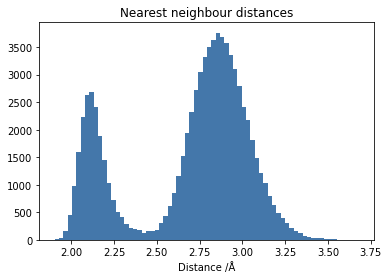

In [9]:
print(nearest_df.corr())

fig, ax = plt.subplots()

nbins = 'fd'
htype = 'bar'

ax.hist(nearest_df.values.ravel(), bins=nbins, histtype=htype)

ax.set_title('Nearest neighbour distances')
ax.set_xlabel('Distance /Å');

In order to tie the remaining `nn`'s to cluster positions we apply a filter that extracts nearest neighour distances that minimise the H\*-Ow separation, which can then be identified to the (ontop) O2-position. Because there is some overlap betweem all `nn`'s we add another criterium that O1 should minimise the OH-Ow angle and that O2 should maximise it. The other distances are kept as ring1 and ring2. 

To summarise:
- O1 is the position which minimises the O\*-Ow distance and **minimises** the O\*-H\*-Ow angle
- O2 is the position which minimises the O\*-Ow distance and **maximises** the O\*-H\*-Ow angle
- Ring1/ring2 are, by rank, the remaining distances that still are part of the first shell ring visible in the heatmaps above

In [11]:
def label_hbond_sites(geo, n_max=4): # <--------------------------------------------------------- MOVE THIS TO HELPER FUNCS
    """O1 = closest neighbour (hemibond); O2 = most linear of the rest
    (on-top); everyone else = ring1, ring2, ... by distance."""
    rows = []
    for frame, row in geo.iterrows():
        o1 = 1  # geo's ranks are already sorted by distance, so rank 1 = closest

        rest = range(2, n_max + 1)
        o2 = max(rest, key=lambda r: row[f'angle_{r}'])  # most linear of what's left

        ring = sorted((r for r in rest if r != o2), key=lambda r: row[f'dist_{r}'])

        labeled = {'frame': frame}
        positions = [('O1', o1), ('O2', o2)] + [(f'ring{i+1}', r) for i, r in enumerate(ring)]
        for label, rank in positions:
            labeled[f'{label}_dist']  = row[f'dist_{rank}']
            labeled[f'{label}_angle'] = row[f'angle_{rank}']
            labeled[f'{label}_atom']  = row[f'atom_{rank}']
        rows.append(labeled)

    return pd.DataFrame(rows).set_index('frame')

try:
    sites = pd.read_json('results/NPT/hbond_sites.json', orient='records').set_index('frame')
except:
    # columns: dist_1..dist_4, angle_1..angle_4, atom_1..atom_4 (rank 1 = closest)
    geo = traj.nearest_neighbor_angles(
        center={'HO': 'O'}, align_to={'HO': 'H'}, target={'H2O': 'O'}, n_max=4
    )

    sites = label_hbond_sites(geo)
    sites.to_json('results/NPT/hbond_sites.json', orient='index')
sites.head()

,O1_dist,O1_angle,O1_atom,O2_dist,O2_angle,O2_atom,ring1_dist,ring1_angle,ring1_atom,ring2_dist,ring2_angle,ring2_atom
frame,,,,,,,,,,,,
0,2.134791,62.633222,54,2.851134,165.156375,60,2.743511,61.553918,6,2.804684,48.980079,93
1,2.199556,68.885794,54,2.823216,171.055360,60,2.723308,55.216261,6,2.800452,54.231791,93
2,2.246550,78.056006,54,2.791903,163.430707,60,2.720994,52.524179,6,2.795915,58.908096,93
3,2.273739,83.349274,54,2.763383,158.236572,60,2.748629,53.113633,6,2.787747,58.252172,93
4,2.286877,85.679400,54,2.741250,161.830247,60,2.780875,54.191493,93,2.781895,57.486038,6


In [12]:
position_df = sites[(col for col in sites if 'dist' in col)]
print(position_df.corr())
position_df.head()

             O1_dist   O2_dist  ring1_dist  ring2_dist
O1_dist     1.000000 -0.120702   -0.065914    0.005634
O2_dist    -0.120702  1.000000    0.100081    0.215417
ring1_dist -0.065914  0.100081    1.000000    0.528343
ring2_dist  0.005634  0.215417    0.528343    1.000000


,O1_dist,O2_dist,ring1_dist,ring2_dist
frame,,,,
0,2.134791,2.851134,2.743511,2.804684
1,2.199556,2.823216,2.723308,2.800452
2,2.246550,2.791903,2.720994,2.795915
3,2.273739,2.763383,2.748629,2.787747
4,2.286877,2.741250,2.780875,2.781895


In [13]:
angle_df = sites[(col for col in sites if 'angle' in col)]
print(angle_df.corr())
angle_df.head()

             O1_angle  O2_angle  ring1_angle  ring2_angle
O1_angle     1.000000 -0.018226     0.031444    -0.045177
O2_angle    -0.018226  1.000000     0.200991     0.225668
ring1_angle  0.031444  0.200991     1.000000    -0.136987
ring2_angle -0.045177  0.225668    -0.136987     1.000000


,O1_angle,O2_angle,ring1_angle,ring2_angle
frame,,,,
0,62.633222,165.156375,61.553918,48.980079
1,68.885794,171.055360,55.216261,54.231791
2,78.056006,163.430707,52.524179,58.908096
3,83.349274,158.236572,53.113633,58.252172
4,85.679400,161.830247,54.191493,57.486038


In [25]:
test_df = sites[(col for col in sites if ('angle' in col) or ('dist' in col))]

In [30]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

clean = position_df.dropna()  # drop any NaN-padded rows first
#clean = test_df.dropna()  # drop any NaN-padded rows first

X = StandardScaler().fit_transform(clean.values)  # see note below

pca = PCA(n_components=clean.shape[1])
scores = pca.fit_transform(X)

print('explained variance ratio:', pca.explained_variance_ratio_)
print('cumulative:', np.cumsum(pca.explained_variance_ratio_))

pca_df = pd.DataFrame(
    scores,
    columns=[f'PC{i+1}' for i in range(scores.shape[1])],
    index=clean.index,
)
pca_df.head()


explained variance ratio: [0.40533102 0.26446318 0.21783869 0.11236711]
cumulative: [0.40533102 0.6697942  0.88763289 1.        ]


,PC1,PC2,PC3,PC4
frame,,,,
0,-0.987775,-0.263347,0.007671,-0.546075
1,-1.257017,0.386586,0.344999,-0.535939
2,-1.425894,0.907384,0.511948,-0.582601
3,-1.438445,1.275811,0.495572,-0.763580
4,-1.384393,1.504741,0.406990,-0.941319


PCA1 exp. var. ratio:  40.5% (40.5%)
PCA2 exp. var. ratio:  67.0% (26.4%)
PCA3 exp. var. ratio:  88.8% (21.8%)
PCA4 exp. var. ratio:  100.0% (11.2%)


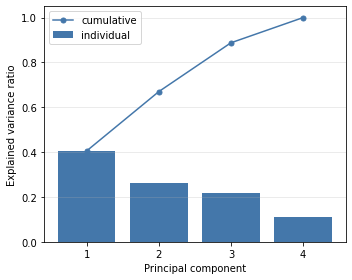

In [31]:
fig, ax = plt.subplots(figsize=(5, 4))

pcs = np.arange(1, len(pca.explained_variance_ratio_) + 1)
individual = pca.explained_variance_ratio_
cumulative = np.cumsum(individual)

for i, var  in enumerate(cumulative):
    print(f'PCA{i+1} exp. var. ratio:  {var:.1%} ({individual[i]:.1%})')


ax.bar(pcs, individual, label='individual')
ax.plot(pcs, cumulative, marker='o', ms=5, lw=1.5, label='cumulative')

ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance ratio')
ax.set_xticks(pcs)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y')
plt.tight_layout()


**Analysis:**

From the SDF-plots (heatmaps): The nn1 is the 'hemi-bonded' O1-species and nn4 is the 'ontop' coordinated water. The other two neighbours (nn2 and nn3) are perpendicular to the O\*-O2 coordination. *The first two components account for almost all the variance but PC3 accounts for around 15% variance and PC4 for about 7% variance.*

>NOTE: This analysis is non-directional. It only measures whether or not one distance correlates with another. We infer, for nn1 and nn4, which coordination positions they correspond to based on the heatmap. When it comes to nn2 and nn3, we infer from the other positions which these correspond to but **the exact  positions are indistinguishable**.

- PC1: The O1 (hemi-bond) position is uncorrelated to the other coordination distances. The ring positions are strongly correlated to one antoher and moderately correlated to the O2 (ontop) position
  - When the ring positions expand outward, the ontop position does so as well but with a fainter signal
- PC2: When the O1 (hemi-bond) distance increases, the others are not affected much. The other positions show some correlations. When O2 (ontop) goes inward, one of the non-axial neighbours goes inward and the other outward. *Since they are not index bound we cannot now exactly which is which, only that they are correlated in some manner.*
- PC3: O1 positively correlates with one of the non-axial neighbours and negatively to O2 (ontop).
- PC4: The hemi-bond position is unaffected by changes here. The ontop position has a positive correlation to one of the others and a negative correlation to the last.


The O1-position is very 'rigid' in that it does not care about the other ligands in the cluster. Only rarely does changes in the O\*-O1 distance correlate with the other distances. *However, geometry optimisation of a OH\*-w4 cluster results in the disappearance of the O1 position (see further down). This implies that the O1 position is not stable on its own*. **Instead, the water molecules tend to form a hydrogen bond network without the OH\*-species**.

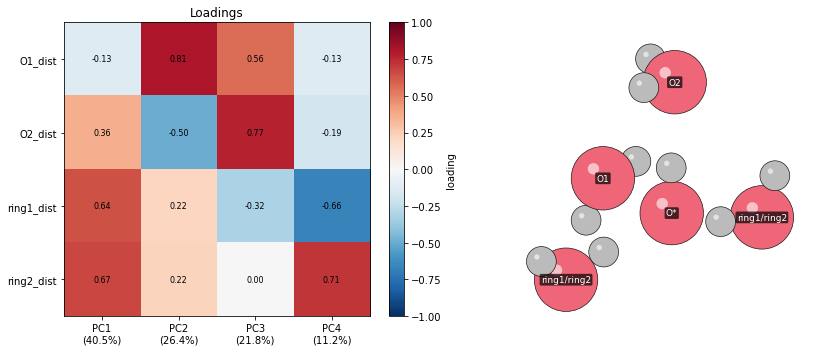

In [32]:
from ase.io import read
from chempiler import plot_structure

loadings = pd.DataFrame(
    pca.components_.T,
    index=clean.columns,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
)

xticklabels = [
    f'{pc}\n({var:.1%})' for pc, var in zip(loadings.columns, pca.explained_variance_ratio_)
]

OH_rad_w4 = read('results/NPT/structures/OH-rad_w4.xyz', index=':')
O_w4_labels = {
    0: 'ring1/ring2',
    3: 'O1',
    6: 'O2',
    9: 'ring1/ring2',
    12: 'O*',
}


fig, (load_plot, cluster_visual) = plt.subplots(1,2, figsize=(6*2,5))


plot_structure(
    OH_rad_w4[0], elev=140.2, azim=-53.7, roll=35.2,
    mark_atoms=O_w4_labels,
    sphere_scale=1.0,
    ax=cluster_visual,
)


im = load_plot.imshow(loadings.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
load_plot.set_title('Loadings')
load_plot.set_xticks(range(loadings.shape[1]))
load_plot.set_xticklabels(xticklabels)
load_plot.set_yticks(range(loadings.shape[0]))
load_plot.set_yticklabels(loadings.index)
for (i, j), v in np.ndenumerate(loadings.values):
    load_plot.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=load_plot, label='loading')
plt.tight_layout()

## Cluster analysis
The following analysis was conducted on (i) dimers (OH*-w1) and (ii) and on first shell clusters (OH*-w4). In (i) we observe two different kinds of structures and and relate each of them to different DFT functionals (BLYP, B3LYP, PBE0, wB97M-V). In (ii) the analysis is threefold:
1. Geometry optimisation of clusters constrained to different angles: Which are angles are optimal?
2. Do the hydrogens at the O1 position (see figure below) tilt inward toward the OH?
3. Does MACE-POLAR-1-M behave more like wB97M-V or one of the other functionals?


### First shell
The molecular nearest neighbour coordination was extracted from the trajectory and saved to a file. Example visuals are shown below.

In [19]:
from ase.io import read

try:
    first_shell_traj = read('results/NPT/HO_nn4.xyz', index=':')
except:
    first_shell_traj = traj.extract_nearest_neighbors(
        'HO', n_neighbors=4,
        output_dir='results/NPT',
        stride=1,
    )

**Interactive 3D visual:**

In [20]:
from chempiler import view3d

# Manual extraction of atom indexes resulted in the following index-name map
oxygen_labels = {
    0: 'O3',
    3: 'O1',
    6: 'O2',
    9: 'O4',
    12: 'O*',
}

# 3D visual with using the above labels
view3d(
    first_shell_traj[1],
    mark_atoms=oxygen_labels,
    radius='vdw',
    show_orientation=True,
    mark_bonds=[('O*', 'O1')],
    bonds=True,
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**2D visual:**

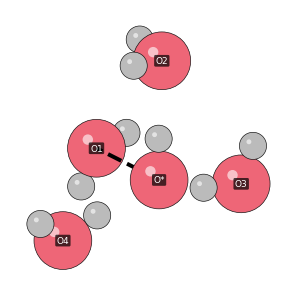

In [21]:
from chempiler import plot_structure

# Static: same elev/azim reproduces that exact orientation, renders on GitHub
fig, ax = plot_structure(
    first_shell_traj[1], elev=140.2, azim=-53.7, roll=35.2,
    mark_atoms=oxygen_labels,
    mark_bonds=[('O*', 'O1')],
    sphere_scale=1.0,
    mark_bond_width=4,
    mark_bond_style='--',
    mark_bond_color='k',
)
fig.savefig('results/NPT/HO_nn4_structure.png', dpi=150, bbox_inches='tight')


#### Cluster optimisations

NPT cluster:
d(O*-O1) = 2.20 Å)


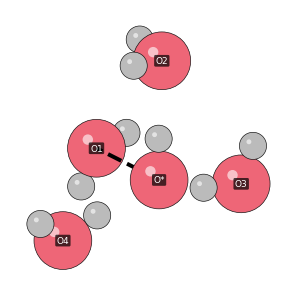

In [42]:
from ase.io import read
import numpy as np
from chempiler import plot_structure

OH_rad_w4 = read('results/NPT/structures/OH-rad_w4.xyz', index=':')

# Manual extraction of atom indexes resulted in the following index-name map
O_w4_labels = {
    0: 'O3',
    3: 'O1',
    6: 'O2',
    9: 'O4',
    12: 'O*',
}

d_OO1 = np.linalg.norm(OH_rad_w4[0][12].position - OH_rad_w4[0][3].position)

print('NPT cluster:')
fig, ax = plot_structure(
    OH_rad_w4[0], elev=140.2, azim=-53.7, roll=35.2,
    mark_atoms=O_w4_labels,
    mark_bonds=[('O*', 'O1')],
    sphere_scale=1.0,
    mark_bond_width=4,
    mark_bond_style='--',
    mark_bond_color='k',
)
print(f'd(O*-O1) = {d_OO1:.2f} Å)')

Optimised wB97M-V cluster:
d(O*-O1) = 3.12 Å)


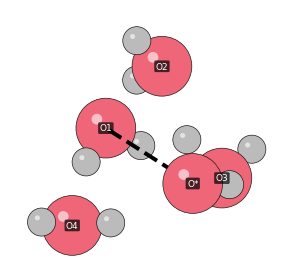

In [43]:
d_OO1_opt = np.linalg.norm(OH_rad_w4[1][12].position - OH_rad_w4[1][3].position)

print('Optimised wB97M-V cluster:')
fig, ax = plot_structure(
    OH_rad_w4[1], elev=140.2, azim=-53.7, roll=35.2,
    mark_atoms=O_w4_labels,
    mark_bonds=[('O*', 'O1')],
    sphere_scale=1.0,
    mark_bond_width=4,
    mark_bond_style='--',
    mark_bond_color='k',
)
print(f'd(O*-O1) = {d_OO1_opt:.2f} Å)')
fig.savefig('results/NPT/structures/OH-rad_w4_frame1_opt.png', dpi=150, bbox_inches='tight')

### First shell + extra neighbour

In [44]:
from chempiler import view3d

# 3D visual with using the above labels
view3d(
     OH_rad_w4[1],
    mark_atoms=O_w4_labels,
    radius='vdw',
    show_orientation=True,
    mark_bonds=[('O*', 'O1')],
    bonds=True,
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [72]:
from ase.io import read

try:
    OH_rad_w5 = read('results/NPT/structures/HO_nn5.xyz', index=':')
except:
    OH_rad_w5 = traj.extract_nearest_neighbors(
        'HO', n_neighbors=5,
        output_dir='results/NPT/structures',
        stride=1,
    )

In [ ]:
from chempiler import view3d
from ase.io import write

# Manual extraction of atom indexes resulted in the following index-name map
O_w5_labels = {
    0: 'O3',
    3: 'O1',
    6: 'O2',
    9: 'O4',
    12: 'O5',
    15: 'O*',
}

idx = 123
#write(f'results/NPT/structures/OH-rad_w5_frame{idx+1}.xyz', OH_rad_w5[idx])

# 3D visual with using the above labels
view3d(
     OH_rad_w5[idx], # I looked at many different clusters but they all looked about the same
    mark_atoms=O_w5_labels,
    #mark_atoms=[a.index for a in OH_rad_w5[1] if a.symbol == 'O'], # <-- Used to constrtuct the map above!
    radius='vdw',
    show_orientation=True,
    mark_bonds=[('O*', 'O1')],
    bonds=True,
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:

OH_rad_w12 = npt_traj.extract_nearest_neighbors(
    'HO', n_neighbors=12,
    output_dir='results/NPT/structures',
    stride=1,
)

In [ ]:
from chempiler import view3d

view3d(
     OH_rad_w12[0], # I looked at many different clusters but they all looked about the same
    #mark_atoms=O_w5_labels,
    #mark_atoms=[a.index for a in OH_rad_w12[0] if a.symbol == 'O'], # <-- Used to constrtuct the map above!
    radius='vdw',
    show_orientation=True,
    #bonds=True,'
)

NameError: name 'OH_rad_large' is not defined